Standard imports, plus creating the output folders if they don't already exist (so this notebook can be re-run safely without manual folder setup).

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from shapely import wkt
import os

# Make sure output folders exist
for folder in ["../outputs/maps", "../outputs/figures", "../outputs/tables", "../outputs/models"]:
    os.makedirs(folder, exist_ok=True)

print("Output folders ready.")

Output folders ready.


## 1. Hexagon Grid Map

This is the "base map" figure for the Methodology chapter: it shows the Berlin boundary with the full 1,353-hexagon resolution-8 H3 grid overlaid, with no data coloring yet.

Loads the boundary WKT (same source as NB01) and the plain hex grid (`berlin_h3_res8.geojson`, before any features were joined).

In [ ]:

boundary_df = pd.read_csv("../data/external/berlin_boundary.csv")
berlin_boundary = wkt.loads(boundary_df["location"].iloc[0])
boundary_gdf = gpd.GeoDataFrame({"name": ["Berlin"]}, geometry=[berlin_boundary], crs="EPSG:4326")


hex_grid = gpd.read_file("../data/external/berlin_h3_res8.geojson")

print(f"Boundary loaded: {berlin_boundary.geom_type}")
print(f"Hexagons loaded: {len(hex_grid)}")

Boundary loaded: MultiPolygon
Hexagons loaded: 1353


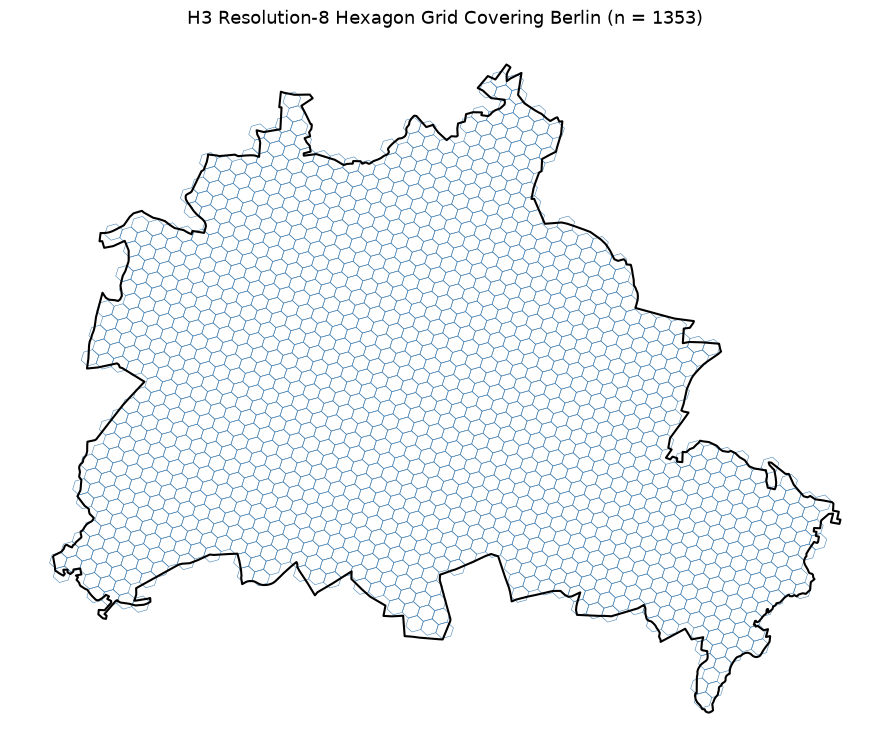

Saved: ../outputs/maps/hex_grid_map.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=2)
hex_grid.plot(ax=ax, facecolor="none", edgecolor="steelblue", linewidth=0.4, zorder=1)

ax.set_title(f"H3 Resolution-8 Hexagon Grid Covering Berlin (n = {len(hex_grid)})", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("../outputs/maps/hex_grid_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/maps/hex_grid_map.png")

## 2. Popular Café Count Choropleth

Shows where popular cafés are actually concentrated across Berlin, hexagon by hexagon. This is the target variable visualized spatially, so it belongs either in the Data/Target Variable section or the EDA section of the Results chapter.

Loads the full feature dataset (has `popular_cafe_count` per hexagon).

In [ ]:
gdf_full = gpd.read_file("../data/processed/berlin_h3_res8_with_all_features.geojson")
print(f"Shape: {gdf_full.shape}")

Shape: (1353, 14)


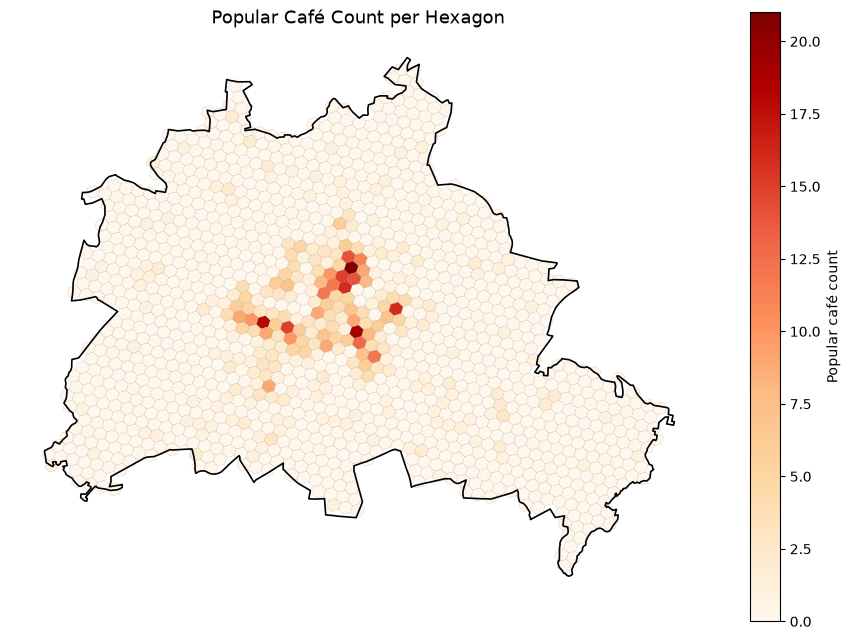

Saved: ../outputs/maps/cafe_count_choropleth.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)
gdf_full.plot(
    column="popular_cafe_count", cmap="OrRd", legend=True,
    ax=ax, edgecolor="grey", linewidth=0.1,
    legend_kwds={"label": "Popular café count", "shrink": 0.7}
)

ax.set_title("Popular Café Count per Hexagon", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("../outputs/maps/cafe_count_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/maps/cafe_count_choropleth.png")

## 3. Popular Café Count Histogram

The distribution shape (heavy zero-inflation, long right tail) is central to justifying the Poisson-objective XGBoost choice. This figure is annotated directly with the zero-inflation percentage and mean/variance, rather than leaving the reader to infer it from prose alone.

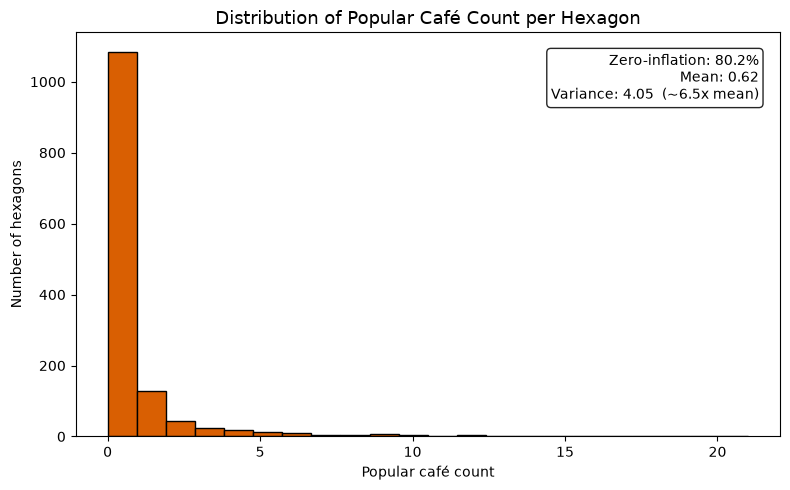

Saved: ../outputs/figures/cafe_count_histogram.png


In [ ]:
zero_pct = (gdf_full["popular_cafe_count"] == 0).mean() * 100
mean_val = gdf_full["popular_cafe_count"].mean()
var_val = gdf_full["popular_cafe_count"].var()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(gdf_full["popular_cafe_count"], bins=22, edgecolor="black", color="#d95f02")

ax.set_title("Distribution of Popular Café Count per Hexagon", fontsize=13)
ax.set_xlabel("Popular café count")
ax.set_ylabel("Number of hexagons")

annotation = (
    f"Zero-inflation: {zero_pct:.1f}%\n"
    f"Mean: {mean_val:.2f}\n"
    f"Variance: {var_val:.2f}  (~{var_val/mean_val:.1f}x mean)"
)
ax.text(0.97, 0.95, annotation, transform=ax.transAxes, fontsize=10,
        va="top", ha="right", bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.savefig("../outputs/figures/cafe_count_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/figures/cafe_count_histogram.png")

## 4. Predictor Feature Distributions Panel

A single reference figure showing all 10 predictor distributions at once. This is useful as an EDA appendix figure or to support the "predictors are right-skewed, count-like variables" observation in the EDA section.

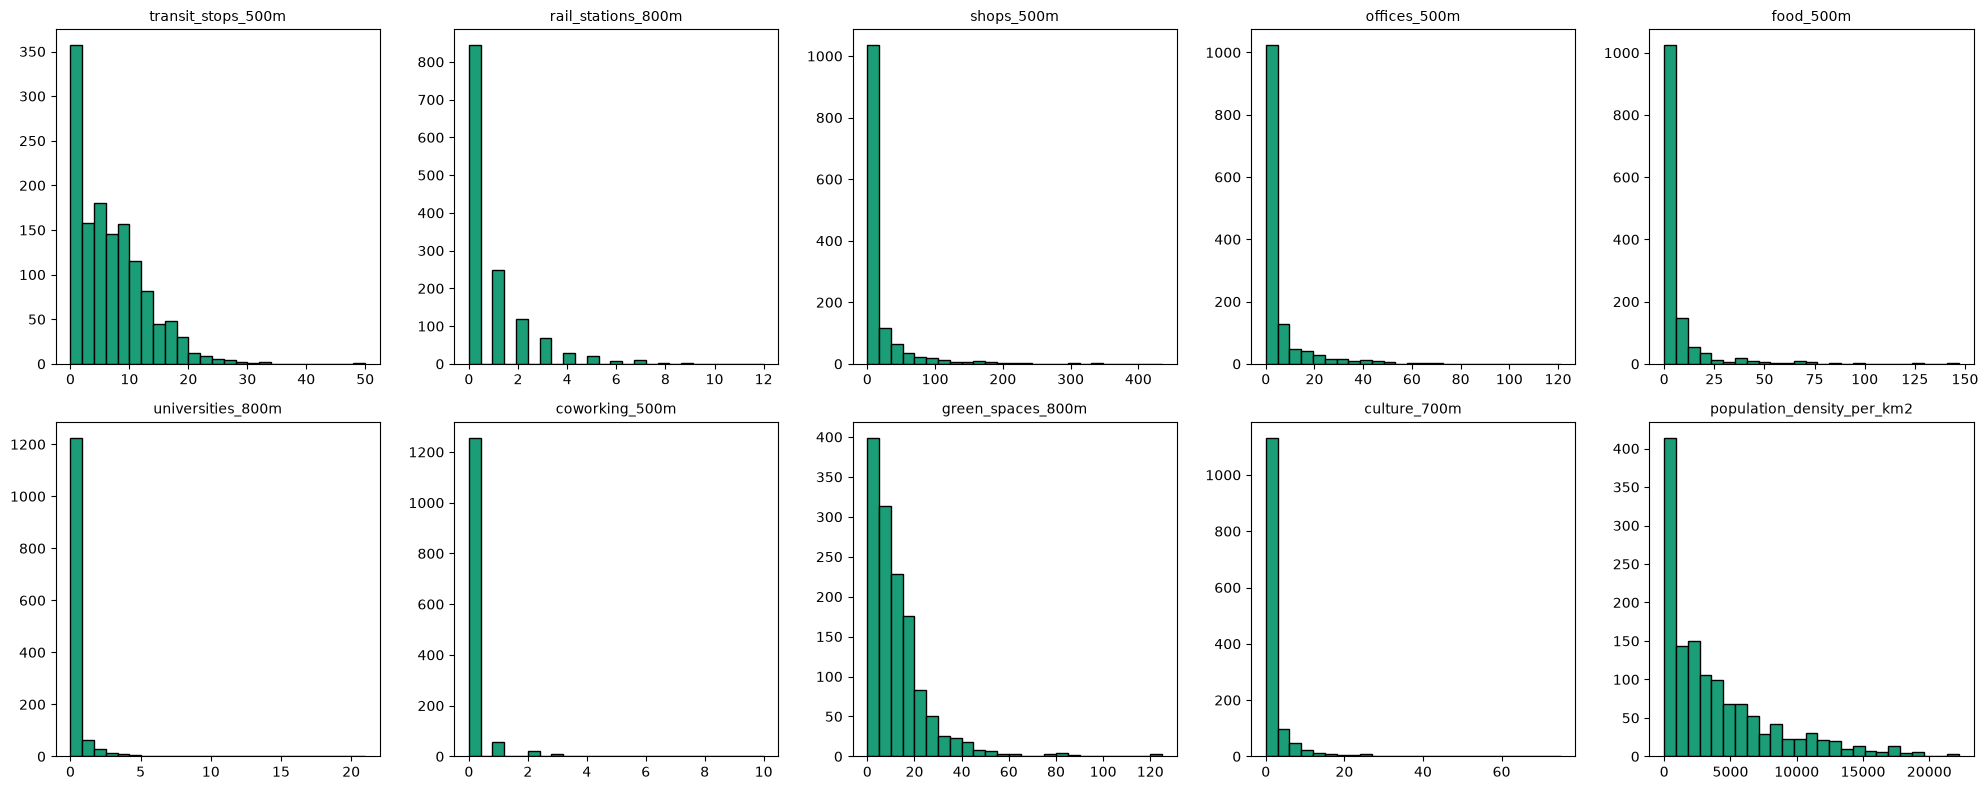

Saved: ../outputs/figures/predictor_distributions_panel.png


In [ ]:
predictors = ['transit_stops_500m', 'rail_stations_800m', 'shops_500m',
              'offices_500m', 'food_500m', 'universities_800m',
              'coworking_500m', 'green_spaces_800m', 'culture_700m',
              'population_density_per_km2']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].hist(gdf_full[col], bins=25, edgecolor="black", color="#1b9e77")
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/predictor_distributions_panel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/figures/predictor_distributions_panel.png")

## 5. Predictor Correlation Heatmap

This is the figure that visually backs up the multicollinearity finding from EDA (shops_500m / food_500m, r = 0.92) and the VIF results reported in section 3.6.

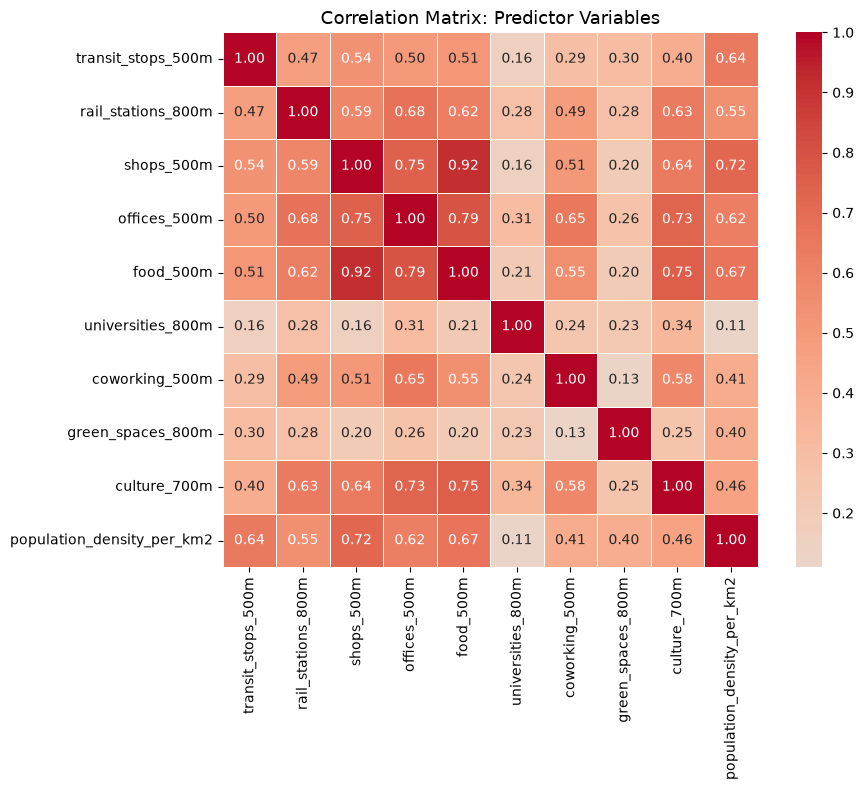

Saved: ../outputs/figures/predictor_correlation_heatmap.png


In [ ]:
corr_matrix = gdf_full[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix: Predictor Variables", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/predictor_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/figures/predictor_correlation_heatmap.png")

## 6. Predictor vs. Target Scatterplots

Shows the raw relationship between each predictor and `popular_cafe_count`, useful in the EDA section to justify moving to a nonlinear model rather than assuming linear relationships upfront.

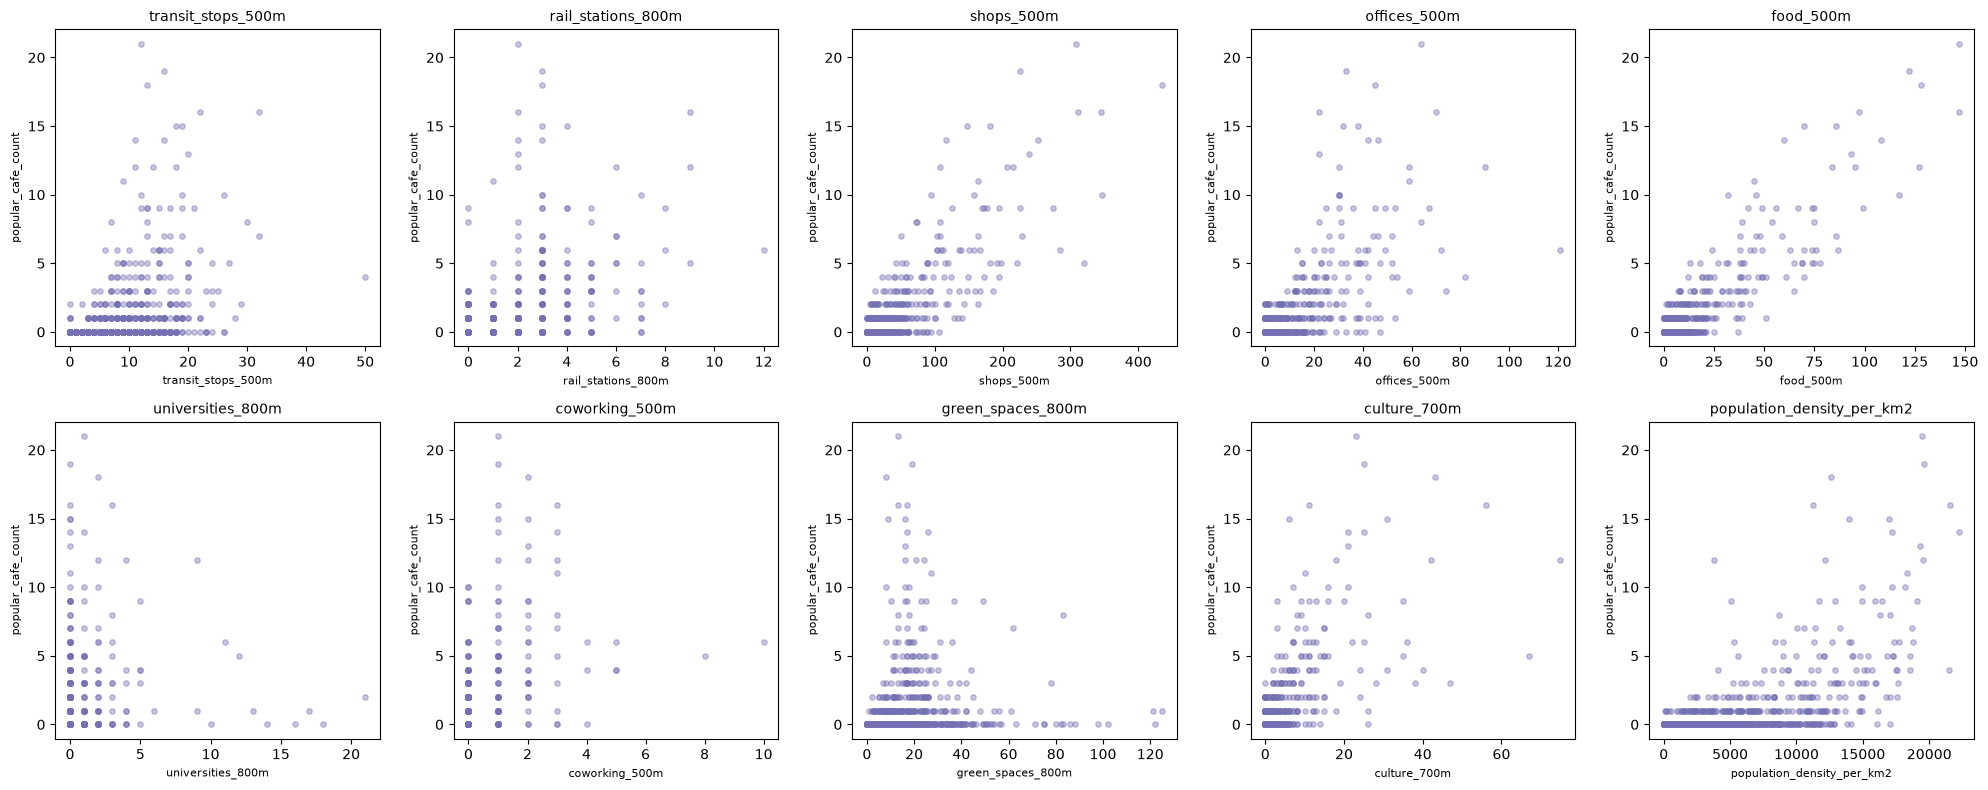

Saved: ../outputs/figures/predictor_target_scatterplots.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(gdf_full[col], gdf_full["popular_cafe_count"], alpha=0.4, s=15, color="#7570b3")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("popular_cafe_count", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/predictor_target_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/figures/predictor_target_scatterplots.png")

## 7. Population Density Choropleth (Matplotlib Backup)

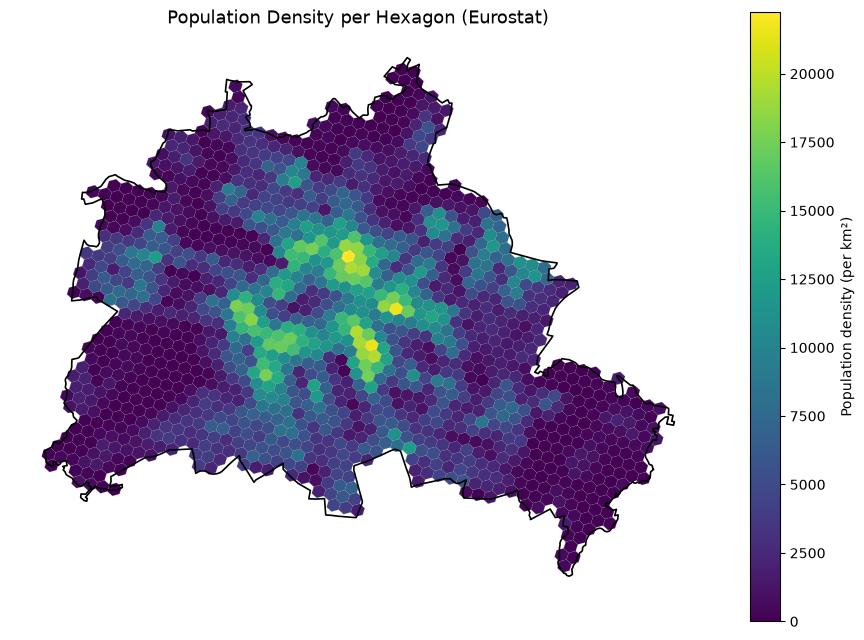

Saved: ../outputs/maps/population_density_choropleth.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)
gdf_full.plot(
    column="population_density_per_km2", cmap="viridis", legend=True,
    ax=ax, edgecolor="grey", linewidth=0.1,
    legend_kwds={"label": "Population density (per km²)", "shrink": 0.7}
)

ax.set_title("Population Density per Hexagon (Eurostat)", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("../outputs/maps/population_density_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/maps/population_density_choropleth.png")

## 8. Opportunity Gap Map (Study 2)

Loads `berlin_h3_opportunity_gap.geojson`, which already has the `gap_category` column from NB09.

In [ ]:
gdf_gap = gpd.read_file("../data/processed/berlin_h3_opportunity_gap.geojson")
print(gdf_gap["gap_category"].value_counts())

gap_category
Matched          1138
Oversaturated     142
Underserved        73
Name: count, dtype: int64


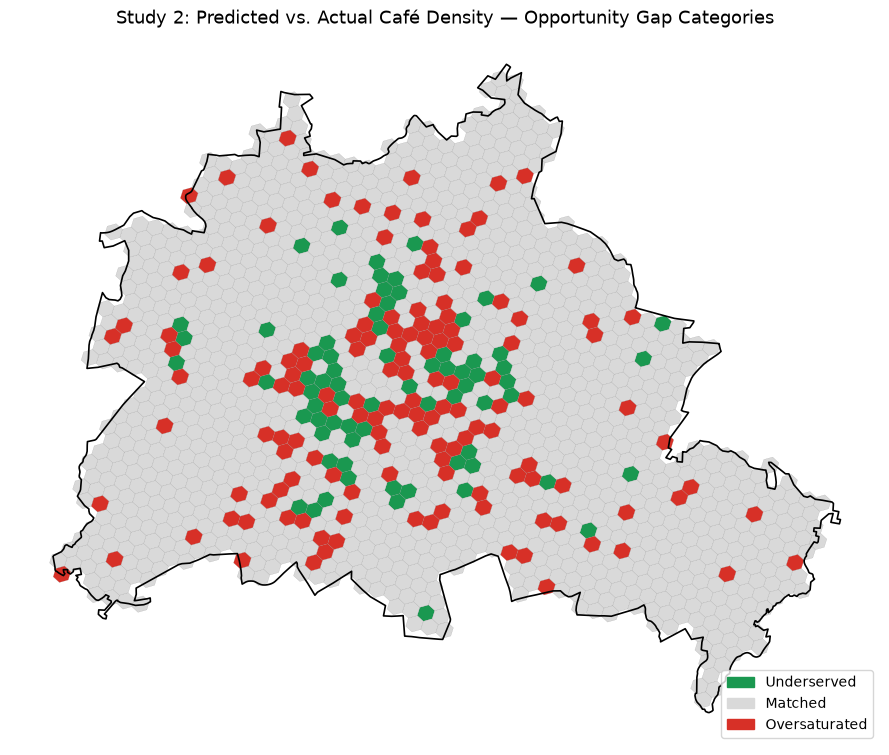

Saved: ../outputs/maps/opportunity_gap_map.png


In [ ]:
category_colors = {
    "Underserved": "#1a9850",   # green: potential opportunity
    "Matched": "#d9d9d9",       # grey: predicted ~ actual
    "Oversaturated": "#d73027", # red: more cafes than model expects
}

fig, ax = plt.subplots(figsize=(9, 9))

boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)
for category, color in category_colors.items():
    subset = gdf_gap[gdf_gap["gap_category"] == category]
    subset.plot(ax=ax, color=color, edgecolor="grey", linewidth=0.1, label=category)

ax.set_title("Study 2: Predicted vs. Actual Café Density — Opportunity Gap Categories", fontsize=13)
ax.set_axis_off()

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in category_colors.items()]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("../outputs/maps/opportunity_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/maps/opportunity_gap_map.png")

## 9. Predictor Feature List Table


In [ ]:
feature_table = pd.DataFrame([
    {"feature_name": "transit_stops_500m", "hypothesis_group": "A: Transport Access", "buffer_distance": "500m",
     "description": "Count of public transit stops (bus/tram) within buffer"},
    {"feature_name": "rail_stations_800m", "hypothesis_group": "A: Transport Access", "buffer_distance": "800m",
     "description": "Count of rail/S-Bahn/U-Bahn stations within buffer"},
    {"feature_name": "shops_500m", "hypothesis_group": "B: Commercial & Leisure Activity", "buffer_distance": "500m",
     "description": "Count of retail shop POIs within buffer"},
    {"feature_name": "food_500m", "hypothesis_group": "B: Commercial & Leisure Activity", "buffer_distance": "500m",
     "description": "Count of food and beverage venue POIs within buffer"},
    {"feature_name": "culture_700m", "hypothesis_group": "B: Commercial & Leisure Activity", "buffer_distance": "700m",
     "description": "Count of cultural venue POIs (museums, theatres, galleries) within buffer"},
    {"feature_name": "offices_500m", "hypothesis_group": "C: Institutional & Workplace Density", "buffer_distance": "500m",
     "description": "Count of office POIs within buffer"},
    {"feature_name": "universities_800m", "hypothesis_group": "C: Institutional & Workplace Density", "buffer_distance": "800m",
     "description": "Count of university/higher-education POIs within buffer"},
    {"feature_name": "coworking_500m", "hypothesis_group": "C: Institutional & Workplace Density", "buffer_distance": "500m",
     "description": "Count of coworking space POIs within buffer"},
    {"feature_name": "green_spaces_800m", "hypothesis_group": "D: Green Space", "buffer_distance": "800m",
     "description": "Count of green space POIs (parks, gardens) within buffer"},
    {"feature_name": "population_density_per_km2", "hypothesis_group": "E: Population Density", "buffer_distance": "N/A (area-weighted)",
     "description": "Population density per km², area-weighted overlay onto H3 grid"},
])

feature_table.to_csv("../outputs/tables/predictor_feature_list.csv", index=False)
print("Saved: ../outputs/tables/predictor_feature_list.csv\n")
feature_table

Saved: ../outputs/tables/predictor_feature_list.csv



,feature_name,hypothesis_group,buffer_distance,description
0,transit_stops_500m,H1: Transport Access,500m,Count of public transit stops (bus/tram) withi...
1,rail_stations_800m,H1: Transport Access,800m,Count of rail/S-Bahn/U-Bahn stations within bu...
2,shops_500m,H2: Commercial & Leisure Activity,500m,Count of retail shop POIs within buffer
3,food_500m,H2: Commercial & Leisure Activity,500m,Count of food and beverage venue POIs within b...
4,culture_700m,H2: Commercial & Leisure Activity,700m,"Count of cultural venue POIs (museums, theatre..."
5,offices_500m,H3: Institutional & Workplace Density,500m,Count of office POIs within buffer
6,universities_800m,H3: Institutional & Workplace Density,800m,Count of university/higher-education POIs with...
7,coworking_500m,H3: Institutional & Workplace Density,500m,Count of coworking space POIs within buffer
8,green_spaces_800m,H4: Green Space,800m,"Count of green space POIs (parks, gardens) wit..."
9,population_density_per_km2,H5: Population Density,N/A (area-weighted),"Population density per km², area-weighted over..."


## 10. Data Source Summary Table

A reference table documenting each data source. It records what each source provided, how it was accessed, and its role in the pipeline. This supports the reproducibility discussion in section 3.3.4.

In [ ]:
source_table = pd.DataFrame([
    {"source": "Google Places API", "role": "Target variable construction", 
     "provides": "Café locations, ratings, review counts (institutional access)",
     "access_method": "Google Places API, via SRH institutional access"},
    {"source": "OpenStreetMap (via osmnx)", "role": "Predictor feature construction (9 features)",
     "provides": "POI locations for transit, shops, food, offices, universities, coworking, culture, green space",
     "access_method": "osmnx Python package, Overpass API queries"},
    {"source": "Eurostat GISCO Population Grid", "role": "Predictor feature construction (1 feature)",
     "provides": "Population density per km², area-weighted onto H3 grid",
     "access_method": "Eurostat GISCO open data portal"},
])

source_table.to_csv("../outputs/tables/data_source_summary.csv", index=False)
print("Saved: ../outputs/tables/data_source_summary.csv\n")
source_table

Saved: ../outputs/tables/data_source_summary.csv



,source,role,provides,access_method
0,Google Places API,Target variable construction,"Café locations, ratings, review counts (instit...","Google Places API, via SRH institutional access"
1,OpenStreetMap (via osmnx),Predictor feature construction (9 features),"POI locations for transit, shops, food, office...","osmnx Python package, Overpass API queries"
2,Eurostat GISCO Population Grid,Predictor feature construction (1 feature),"Population density per km², area-weighted onto...",Eurostat GISCO open data portal
